<a href="https://colab.research.google.com/github/BridgingAISocietySummerSchools/Python-for-Data-Science-Workshop/blob/main/02_advanced_self_learning/12_machine_learning_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Notebook 12 — Machine Learning Basics: The Concepts

> **Advanced & Self-Learning Track — Notebook 12 of 15** · **Estimated time:** 45–55 min · **Difficulty:** Intermediate-beginner
>
> This track is the self-paced deep-dive of the course; the 90-minute live **Introduction Session** lives in `01_introduction/`.

So far you have *described* data: cleaned it (NB 8), plotted it (NB 9), explored it (NB 11). Machine learning
asks a different question — not "what does this data look like?" but **"what can this data predict?"**

This notebook is deliberately **concept-first**. There is code in every section, but the code is here to make an
idea visible, not to tour the library. The next notebook, `13_scikit_learn_workflow.ipynb`, is the practical
counterpart: pipelines, cross-validation, hyperparameter search. Read this one first and that one will feel obvious.

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. Explain how machine learning differs from ordinary programming — and why "a model is a function fitted to data".
2. Tell **supervised** from **unsupervised** learning, and say what clustering does *not* give you.
3. Use the `X` / `y` convention: rows = observations, columns = features, target separate.
4. Explain why evaluating a model on its own training data is cheating, and split data with `train_test_split`.
5. Recite the **ML workflow loop** and walk a concrete problem through every step.
6. Distinguish **classification** (a category) from **regression** (a number), and fit a simple model of each.
7. Read a **confusion matrix** in words, and say when accuracy lies — plus MAE / RMSE / R² for regression.
8. Recognise **underfitting, overfitting and the sweet spot** from train-vs-test score curves.
9. Name the honest limits of a trained model: correlation, bias, and what a good test score does *not* prove.

## ✅ Prerequisites

- **Notebooks 7–11** of this track: pandas (`07`), cleaning (`08`), matplotlib and seaborn (`09`–`10`), EDA (`11`).
- **NumPy** from notebook `06` — arrays, `shape`, boolean masks.
- No mathematics beyond "a straight line has a slope". No prior ML experience assumed.

⬅️ **Previous:** [`11_exploratory_data_analysis.ipynb`](11_exploratory_data_analysis.ipynb) · ➡️ **Next:** [`13_scikit_learn_workflow.ipynb`](13_scikit_learn_workflow.ipynb)

## 1. Setup

One cell, run once. Everything below uses only **NumPy, pandas, matplotlib and scikit-learn** — all preinstalled
in Google Colab — and only datasets that ship *inside* scikit-learn, so nothing is downloaded.

The colours follow the [Bridging AI & Society](https://bridgingaiandsociety.org) summer-school brand, so every
chart in this course looks like part of one family.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Bundled datasets — no network access needed
from sklearn.datasets import (
    load_iris, load_wine, load_breast_cancer, load_diabetes, make_blobs, make_classification,
)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

# --- Bridging AI & Society course plot style -------------------------------
BAS_BLUE = "#416bcc"   # brand accent (lapis blue) — primary series
BAS_INK  = "#1c2025"   # brand ink — text/edges where needed
# supporting colours, chosen to sit well next to the lapis accent:
BAS_AMBER  = "#d9822b"   # secondary series / contrast
BAS_GREEN  = "#3a9e6e"   # "good" / positive
BAS_RED    = "#c8504f"   # "bad" / warnings / errors
BAS_PURPLE = "#7a5fb5"   # tertiary series
BAS_GREY   = "#8a919c"   # de-emphasised / reference lines
BAS_PALETTE = [BAS_BLUE, BAS_AMBER, BAS_GREEN, BAS_RED, BAS_PURPLE, BAS_GREY]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=BAS_PALETTE)
plt.rcParams.update({
    "figure.figsize"   : (8, 5),
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# Silence a known false-positive RuntimeWarning that NumPy's matmul emits on
# some macOS (Accelerate) builds. The computed results are unaffected, and on
# other platforms (e.g. Google Colab) the warning never fires — so this
# filter is harmless there too.
warnings.filterwarnings("ignore", message=".*encountered in matmul")

# One random seed for the whole notebook -> identical numbers every re-run
RANDOM_STATE = 42

import sklearn
print(f"scikit-learn {sklearn.__version__} · numpy {np.__version__} · pandas {pd.__version__}")

scikit-learn 1.6.1 · numpy 2.0.2 · pandas 2.3.3


## 2. What machine learning actually is

Ordinary programming and machine learning solve problems from opposite ends.

| | Ordinary programming | Machine learning |
|---|---|---|
| **You provide** | the *rules* (and data) | the *examples* (data + answers) |
| **The computer produces** | answers | the *rules* |
| **You debug by** | reading the code | changing the data, the features, or the model |
| **Good when** | the rule is known and stateable | the rule is real but nobody can write it down |

That is the whole idea. If you can state the rule — "an invoice is overdue when `today > due_date`" — write an
`if` statement. Do not use machine learning. But nobody can write down the rule that separates a photo of a cat
from a photo of a dog, or the rule that says which patients will respond to a drug. Those rules exist in the
data; ML *fits* them.

The technical phrasing is worth memorising:

> **A model is a function fitted to data.** It takes features in, returns a prediction out. "Training" means
> choosing the function's internal numbers so that its outputs match the known answers as closely as possible.

Let's make that concrete. Below are 240 measurements of two things — call them `feature_1` and `feature_2` — from
two groups (say, two soil samples, two customer types, two cell types). We want to tell the groups apart.

**Attempt 1 (ordinary programming):** we look at the plot and hand-write a rule.
**Attempt 2 (machine learning):** we hand the same points to `LogisticRegression` and let it find a boundary.

In [2]:
# Two overlapping groups, 240 observations, 2 features each
X_demo, y_demo = make_blobs(
    n_samples=240, centers=[(-1, -2), (1, 2)], cluster_std=1.6, random_state=RANDOM_STATE,
)

# --- Attempt 1: a hand-written rule ---------------------------------------
def hand_written_rule(x1):
    """Our human guess: group 1 if feature_1 is positive."""
    return 1 if x1 > 0 else 0

pred_hand = np.array([hand_written_rule(row[0]) for row in X_demo])
acc_hand = accuracy_score(y_demo, pred_hand)

# --- Attempt 2: let the machine find the rule -----------------------------
model_demo = LogisticRegression().fit(X_demo, y_demo)   # <- "fit" = learn the rule
pred_learned = model_demo.predict(X_demo)
acc_learned = accuracy_score(y_demo, pred_learned)

print(f"Hand-written rule 'feature_1 > 0' : {acc_hand:.1%} correct")
print(f"Learned rule (LogisticRegression) : {acc_learned:.1%} correct")
print()
print("The learned rule, written out:")
w1, w2 = model_demo.coef_[0]
b = model_demo.intercept_[0]
print(f"  predict group 1 when  {w1:.2f}*feature_1 {w2:+.2f}*feature_2 {b:+.2f} > 0")

Hand-written rule 'feature_1 > 0' : 77.1% correct
Learned rule (LogisticRegression) : 93.3% correct

The learned rule, written out:
  predict group 1 when  0.74*feature_1 +1.42*feature_2 -0.25 > 0


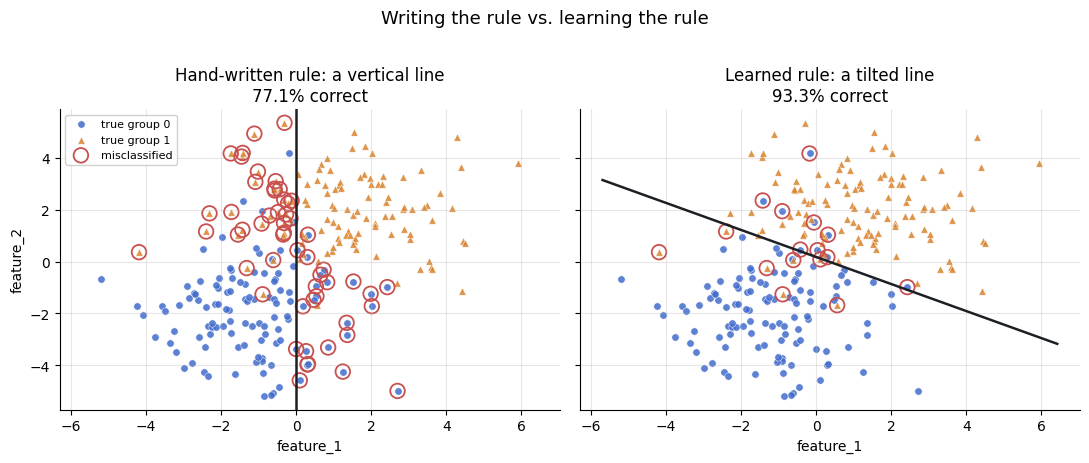

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

for ax, (title, pred, acc) in zip(axes, [
    ("Hand-written rule: a vertical line", pred_hand, acc_hand),
    ("Learned rule: a tilted line", pred_learned, acc_learned),
]):
    for group, colour, marker in [(0, BAS_BLUE, "o"), (1, BAS_AMBER, "^")]:
        sel = y_demo == group
        ax.scatter(X_demo[sel, 0], X_demo[sel, 1], c=colour, marker=marker,
                   s=28, alpha=0.85, edgecolors="white", linewidths=0.4,
                   label=f"true group {group}")
    # mark the points this rule gets wrong
    wrong = pred != y_demo
    ax.scatter(X_demo[wrong, 0], X_demo[wrong, 1], facecolors="none",
               edgecolors=BAS_RED, s=110, linewidths=1.3, label="misclassified")
    ax.set_title(f"{title}\n{acc:.1%} correct")
    ax.set_xlabel("feature_1")

# the two decision boundaries
axes[0].axvline(0, color=BAS_INK, lw=1.8)
xs = np.linspace(X_demo[:, 0].min() - 0.5, X_demo[:, 0].max() + 0.5, 100)
axes[1].plot(xs, -(w1 * xs + b) / w2, color=BAS_INK, lw=1.8)

axes[0].set_ylabel("feature_2")
axes[0].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle("Writing the rule vs. learning the rule", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The learned boundary is **tilted**, because it uses *both* features. Our hand-written rule only looked at
`feature_1` and threw away half the information — the red circles are the price. With two features you could
eventually eyeball a better line yourself; with thirty features you could not, and that is exactly when ML earns
its keep.

Three vocabulary items you now own:

- **`.fit(X, y)`** — training: look at examples and answers, adjust the internal numbers.
- **`.predict(X)`** — inference: apply the fitted function to new rows.
- **`model.coef_`** — the numbers that *are* the learned rule. For a linear model you can literally read them out.

⚠️ One honest caveat about the cell above: we scored both rules on the very same 240 points we fitted on. That is
a mistake, and section 5 is about why.

## 3. Supervised vs. unsupervised learning

The first fork in the road, and it is decided by one question: **do you have the answers?**

| | Supervised learning | Unsupervised learning |
|---|---|---|
| **Data** | features `X` **and** labels `y` | features `X` only |
| **Question** | "predict the label of a new row" | "what structure is in here?" |
| **Typical tasks** | classification, regression | clustering, dimensionality reduction |
| **Examples** | spam / not spam, house price, diagnosis | customer segments, topic groups, anomaly detection |
| **Success is** | measurable against the truth | a matter of interpretation |

Getting labels is usually the expensive part — somebody has to diagnose the patients, mark the spam, measure the
outcome. Unsupervised learning is cheap because it needs none of that, but it also **cannot tell you what its
groups mean**.

Let's prove that on the classic **iris** dataset: 150 flowers, three species, and we use just two measurements
(petal length and petal width) so we can see everything on one plot.

In [4]:
iris = load_iris()
X_iris = iris.data[:, 2:4]          # petal length, petal width (cm)
y_iris = iris.target                # 0 = setosa, 1 = versicolor, 2 = virginica

# --- SUPERVISED: we give the model the species labels --------------------
Xtr, Xte, ytr, yte = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=RANDOM_STATE, stratify=y_iris,
)
supervised = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
print(f"Supervised classifier, accuracy on unseen flowers: {supervised.score(Xte, yte):.1%}")

# --- UNSUPERVISED: we hide the labels and ask for 3 groups ---------------
unsupervised = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_iris)
clusters = unsupervised.labels_     # numbers 0/1/2 with NO meaning attached

print("\nWhich species landed in which cluster?")
print(pd.crosstab(clusters, pd.Series(y_iris).map(dict(enumerate(iris.target_names))),
                  rownames=["cluster"], colnames=["true species"]))

Supervised classifier, accuracy on unseen flowers: 93.3%

Which species landed in which cluster?
true species  setosa  versicolor  virginica
cluster                                    
0                  0           2         46
1                 50           0          0
2                  0          48          4


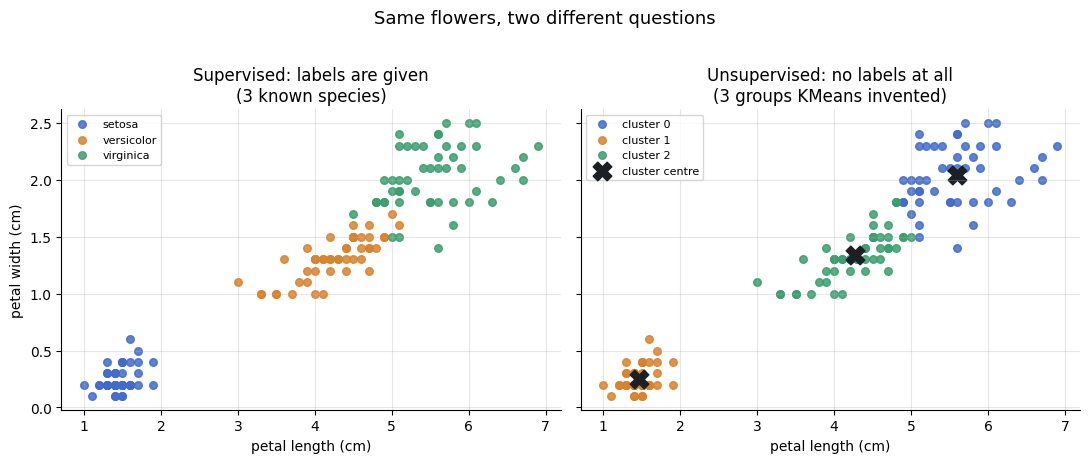

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

# left: the truth (supervised learning gets to see this)
for k, name in enumerate(iris.target_names):
    sel = y_iris == k
    axes[0].scatter(X_iris[sel, 0], X_iris[sel, 1], s=30, alpha=0.85,
                    color=BAS_PALETTE[k], label=name)
axes[0].set_title("Supervised: labels are given\n(3 known species)")
axes[0].legend(fontsize=8)

# right: what KMeans found without labels
for k in range(3):
    sel = clusters == k
    axes[1].scatter(X_iris[sel, 0], X_iris[sel, 1], s=30, alpha=0.85,
                    color=BAS_PALETTE[k], label=f"cluster {k}")
axes[1].scatter(*unsupervised.cluster_centers_.T, marker="X", s=180,
                c=BAS_INK, label="cluster centre")
axes[1].set_title("Unsupervised: no labels at all\n(3 groups KMeans invented)")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel("petal length (cm)")
axes[0].set_ylabel("petal width (cm)")
fig.suptitle("Same flowers, two different questions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Read the cross-tabulation carefully, because it contains the single most useful lesson about clustering:

- One cluster is a perfect match for **setosa** — those 50 flowers are far away from everything else.
- The other two clusters *mostly* line up with versicolor and virginica, but they are **not the same groups**:
  a handful of flowers sit on the wrong side of the invented border.
- And the cluster **numbers are arbitrary**. Re-run with a different `random_state` and "cluster 0" may become
  "cluster 2". KMeans never learns the word *setosa*; it has never seen it.

Notice, too, the sleight of hand in that table: we could only line clusters up against species *because we had the
labels all along*. In a genuine unsupervised problem there is no column to check against — you get three groups
and a decision to make about what, if anything, they are.

So clustering gives you *candidate structure*, not truth. It is a hypothesis generator: "there seem to be three
kinds of thing in here — go and find out what they are." In a societal context that distinction matters a lot.
An algorithm that segments people into groups has not discovered natural categories of people; it has found
regions in whatever features you happened to measure.

## 4. Features and target — the `X` / `y` convention

Every supervised ML library in Python expects your data in the same shape:

- **`X`** — the **features** (also: inputs, predictors, independent variables, "the columns you know").
  A 2-D table: **one row = one observation, one column = one feature**. Shape `(n_samples, n_features)`.
- **`y`** — the **target** (also: label, outcome, dependent variable, "the column you want").
  A 1-D array with **one value per row of `X`**. Shape `(n_samples,)`.

Capital `X` for the matrix, lowercase `y` for the vector — a maths convention that survived into the code. The
one rule you must never break: **row `i` of `X` and element `i` of `y` describe the same thing.** If you sort or
filter one, do the same to the other (or, better, do it in a DataFrame while they are still side by side).

In [6]:
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["species"] = [iris.target_names[k] for k in iris.target]

print("The data as a table (what a human reads):")
print(iris_df.head())

# The split into features and target
X_full = iris_df[iris.feature_names]        # 4 features
y_full = iris.target                        # the answer column

print(f"\nX: {X_full.shape[0]} observations x {X_full.shape[1]} features   -> 2-D")
print(f"y: {y_full.shape[0]} answers                     -> 1-D")
print(f"\nRow 0 of X : {X_full.iloc[0].tolist()}")
print(f"y[0]       : {y_full[0]}  ({iris.target_names[y_full[0]]})   <- same flower")

The data as a table (what a human reads):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

X: 150 observations x 4 features   -> 2-D
y: 150 answers                     -> 1-D

Row 0 of X : [5.1, 3.5, 1.4, 0.2]
y[0]       : 0  (setosa)   <- same flower


**Feature engineering** is the step where you *build better columns*, and it is where domain knowledge lives.
A model can only combine the features you give it, so a well-chosen column can beat a fancier algorithm: from a
date, extract "weekday" and "is public holiday"; from height and weight, compute BMI; from a raw sensor trace,
extract its mean, slope and peak. Nothing in scikit-learn knows that a Tuesday resembles a Wednesday, or that
mass over height squared is medically meaningful — you know that, and a feature is how you tell the model. This
is also where bias enters most quietly: choosing to include postcode, or to leave out treatment history, is a
modelling decision with consequences long before any algorithm runs.

## 5. Training and test data — the exam analogy

Here is the mistake every beginner makes exactly once.

> You are a teacher. You want to know whether your students understood the material. You hand out an exam whose
> questions they have already seen, **with the answer sheet attached**. Everyone scores 100%. You have learned
> nothing about understanding — only about memory.

Scoring a model on the data it was trained on is that exam. A flexible model can memorise its training set
outright and look perfect while being useless on anything new. So we hold data back:

- **Training set** (typically 70–80%) — the model sees features *and* answers. This is where fitting happens.
- **Test set** (typically 20–30%) — locked in a drawer until the very end, then used **once** to estimate how the
  model will do on data it has never met.

`train_test_split` does the splitting, and two of its arguments matter enormously:

- **`random_state=42`** — fixes the shuffle so that you, your colleague, and your reviewer get *the same split*
  and therefore the same numbers. Reproducibility is not a nicety; without it "my accuracy is 0.91" is unfalsifiable.
- **`stratify=y`** — keeps the class proportions of the full dataset in both halves, as closely as whole rows
  allow (expect agreement to a fraction of a percentage point, not to the third decimal). Essential whenever
  classes are unbalanced: without it a rare class can land almost entirely in one side of the split by chance.

In [7]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine,
    test_size=0.25,             # 25% held back
    random_state=RANDOM_STATE,  # reproducible shuffle
    stratify=y_wine,            # keep class proportions
)

print(f"full dataset : {X_wine.shape[0]} wines, {X_wine.shape[1]} features")
print(f"training set : {X_train.shape[0]} wines   (model sees the answers)")
print(f"test set     : {X_test.shape[0]} wines   (locked in the drawer)")

props = pd.DataFrame({
    "full"  : np.bincount(y_wine)  / len(y_wine),
    "train" : np.bincount(y_train) / len(y_train),
    "test"  : np.bincount(y_test)  / len(y_test),
}, index=wine.target_names).round(3)
print("\nClass proportions preserved by stratify=y:")
print(props)

# Now the exam-with-the-answer-sheet, measured
memoriser = DecisionTreeClassifier(random_state=RANDOM_STATE)   # no depth limit
memoriser.fit(X_train, y_train)
print(f"\nAccuracy on the TRAINING set : {memoriser.score(X_train, y_train):.1%}  <- the answer sheet")
print(f"Accuracy on the TEST set     : {memoriser.score(X_test, y_test):.1%}  <- the honest number")

full dataset : 178 wines, 13 features
training set : 133 wines   (model sees the answers)
test set     : 45 wines   (locked in the drawer)

Class proportions preserved by stratify=y:
          full  train   test
class_0  0.331  0.331  0.333
class_1  0.399  0.398  0.400
class_2  0.270  0.271  0.267

Accuracy on the TRAINING set : 100.0%  <- the answer sheet
Accuracy on the TEST set     : 95.6%  <- the honest number


A perfect **100% on training data is a warning sign, not an achievement** — an unrestricted decision tree can
always grow enough branches to file every training row away individually. The test score is the number you
report, and the *gap between the two* is your first diagnostic (section 9 makes it a picture).

Two rules that follow, and that people break under deadline pressure:

1. **Split first, then do everything else.** Fitting a scaler, choosing features, or imputing missing values on
   the full dataset lets information from the test set leak into training — the score you report is then
   optimistically wrong. (Notebook 13 shows the tool that prevents this by construction: `Pipeline`.)
2. **Look at the test set once.** If you tune your model until the test score is nice, the test set has quietly
   become a second training set. For repeated tuning you need cross-validation or a third *validation* split —
   again, notebook 13.

## 6. The ML workflow — one loop, eight steps

Everything in applied machine learning is this loop. Learn it well enough to recite it; the rest of your ML
education is filling in detail under each arrow.

```text
  1. DEFINE the question       what exactly are we predicting, and for whom?
              |
  2. GET & CLEAN the data      missing values, types, outliers        (NB 8)
              |
  3. SPLIT                     train / test, stratified, fixed seed
              |
  4. CHOOSE a model            start simple; get a trivial baseline first
              |
  5. FIT                       model.fit(X_train, y_train)
              |
  6. PREDICT                   model.predict(X_test)
              |
  7. EVALUATE                  a metric that matches the consequences
              |
  8. ITERATE  ------------->   back to step 2 or 4: better features,
                               a different model, or more data
```

Two remarks before we walk it:

- Steps 1 and 2 take most of the real time. Step 5 is one line.
- Step 8 loops back to 2 or 4 — **never** to 3. Re-splitting until the numbers look good is self-deception.

Now the same loop, executed, on the iris petal data.

In [8]:
# ---- STEP 1: define the question ----------------------------------------
# "Given a flower's petal length and width, which of the three iris species is it?"
# -> supervised, classification, 3 classes.

# ---- STEP 2: get and clean the data ------------------------------------
X, y = iris.data[:, 2:4], iris.target
print(f"STEP 2  {X.shape[0]} rows, {X.shape[1]} features, "
      f"missing values: {np.isnan(X).sum()}")

# ---- STEP 3: split ------------------------------------------------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f"STEP 3  {len(X_tr)} train / {len(X_te)} test")

# ---- STEP 4: choose a model (simple on purpose) -------------------------
clf = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)
print(f"STEP 4  {clf.__class__.__name__}(max_depth=2)")

# ---- STEP 5: fit --------------------------------------------------------
clf.fit(X_tr, y_tr)
print("STEP 5  fitted")

# ---- STEP 6: predict ----------------------------------------------------
y_pred = clf.predict(X_te)
print(f"STEP 6  first 8 predictions: {y_pred[:8]}")
print(f"        the true answers   : {y_te[:8]}")

# ---- STEP 7: evaluate ---------------------------------------------------
print(f"STEP 7  test accuracy {accuracy_score(y_te, y_pred):.1%} "
      f"(train {clf.score(X_tr, y_tr):.1%})")

# ---- STEP 8: iterate ----------------------------------------------------
for depth in (1, 2, 3, 5):
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    print(f"STEP 8  max_depth={depth}: train {m.score(X_tr, y_tr):.1%}  test {m.score(X_te, y_te):.1%}")

STEP 2  150 rows, 2 features, missing values: 0
STEP 3  112 train / 38 test
STEP 4  DecisionTreeClassifier(max_depth=2)
STEP 5  fitted
STEP 6  first 8 predictions: [0 1 1 1 0 1 1 2]
        the true answers   : [0 1 1 1 0 1 2 2]
STEP 7  test accuracy 94.7% (train 96.4%)
STEP 8  max_depth=1: train 67.0%  test 65.8%
STEP 8  max_depth=2: train 96.4%  test 94.7%
STEP 8  max_depth=3: train 98.2%  test 92.1%
STEP 8  max_depth=5: train 99.1%  test 92.1%


That is a complete machine-learning project. Twelve lines of substance, and the printed output already tells a
story: `max_depth=1` is too crude to separate three species, and pushing the depth up buys accuracy on the
training set that does not transfer. Hold that thought — it is section 9.

Notice also what step 4 did **not** do: reach for the fanciest model available. A simple model that you can
inspect, explain and debug is worth a great deal, especially when a person is affected by its output.

## 7. Classification vs. regression

Supervised learning splits again, on the *type of the target*:

| | **Classification** | **Regression** |
|---|---|---|
| `y` is | a category (finite, unordered) | a number (continuous) |
| Question | "which one?" | "how much?" |
| Examples | malignant / benign, spam / ham, which species | price, temperature, disease progression |
| Simple models | `LogisticRegression`, `DecisionTreeClassifier` | `LinearRegression`, `DecisionTreeRegressor` |
| Scored with | accuracy, precision, recall, F1 | MAE, RMSE, R² |

The API is identical — `.fit()`, `.predict()`, `.score()` — which is scikit-learn's best design decision. Only
the estimator class and the metrics change. Beware one naming trap: **`LogisticRegression` is a classifier**,
despite its name.

### 7a. Classification — breast-cancer diagnosis

569 tumour biopsies, 30 numeric measurements each (radius, texture, concavity, …), and a two-class target:
**malignant** or **benign**. The task is realistic and the stakes are the reason we will spend a whole section
on metrics.

In [9]:
cancer = load_breast_cancer()
print(f"{cancer.data.shape[0]} biopsies x {cancer.data.shape[1]} features")
print(f"classes: {' / '.join(cancer.target_names)} "
      f"-> counts {np.bincount(cancer.target)} (0 = malignant, 1 = benign)")

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    cancer.data, cancer.target, test_size=0.25,
    random_state=RANDOM_STATE, stratify=cancer.target)

cancer_clf = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
cancer_clf.fit(Xc_tr, yc_tr)
yc_pred = cancer_clf.predict(Xc_te)

print(f"\nTest accuracy: {accuracy_score(yc_te, yc_pred):.1%} on {len(yc_te)} held-out biopsies")

# A classifier can also report how sure it is. For a decision tree these
# "probabilities" are simply the class proportions in the leaf a biopsy fell
# into -- a rough confidence, not a calibrated risk estimate.
probs = cancer_clf.predict_proba(Xc_te[:3])
for i, p in enumerate(probs):
    print(f"biopsy {i}: P(malignant)={p[0]:.2f}  P(benign)={p[1]:.2f}  -> "
          f"{cancer.target_names[yc_pred[i]]}")

569 biopsies x 30 features
classes: malignant / benign -> counts [212 357] (0 = malignant, 1 = benign)

Test accuracy: 94.4% on 143 held-out biopsies
biopsy 0: P(malignant)=0.01  P(benign)=0.99  -> benign
biopsy 1: P(malignant)=1.00  P(benign)=0.00  -> malignant
biopsy 2: P(malignant)=0.90  P(benign)=0.10  -> malignant


### 7b. Regression — disease progression

Same API, different target. The **diabetes** dataset has 442 patients, 10 standardised features (age, sex, BMI,
blood pressure, six blood serum measurements) and a target that is a *number*: a quantitative measure of disease
progression one year after baseline, ranging from 25 to 346.

In [10]:
diabetes = load_diabetes()
print(f"{diabetes.data.shape[0]} patients x {diabetes.data.shape[1]} features")
print(f"target: continuous, min {diabetes.target.min():.0f}, "
      f"max {diabetes.target.max():.0f}, mean {diabetes.target.mean():.1f}")

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    diabetes.data, diabetes.target, test_size=0.25, random_state=RANDOM_STATE)

reg = LinearRegression().fit(Xd_tr, yd_tr)
yd_pred = reg.predict(Xd_te)

print("\nFirst 5 predictions vs. truth:")
for pred, true in zip(yd_pred[:5], yd_te[:5]):
    print(f"  predicted {pred:6.1f}   actual {true:6.1f}   error {pred - true:+6.1f}")

# A linear model is a formula you can read
coefs = pd.Series(reg.coef_, index=diabetes.feature_names).sort_values(key=abs, ascending=False)
print(f"\nLearned formula: prediction = {reg.intercept_:.1f} + sum(coefficient x feature)")
print("Three largest coefficients:")
print(coefs.head(3).round(1))

442 patients x 10 features
target: continuous, min 25, max 346, mean 152.1

First 5 predictions vs. truth:
  predicted  137.9   actual  219.0   error  -81.1
  predicted  182.5   actual   70.0   error +112.5
  predicted  129.9   actual  202.0   error  -72.1
  predicted  292.6   actual  230.0   error  +62.6
  predicted  124.9   actual  111.0   error  +13.9

Learned formula: prediction = 151.7 + sum(coefficient x feature)
Three largest coefficients:
s1    -918.5
s5     695.8
bmi    532.0
dtype: float64


Note the crucial difference in the output: a classifier's prediction is either right or wrong, but a regressor's
prediction is **almost always wrong** — the question is only *by how much*. "Accuracy" is meaningless here, which
is why regression needs its own metrics.

## 8. Model evaluation — choosing a number that means something

### 8a. Accuracy, and when it lies

**Accuracy** = fraction of predictions that are correct. Intuitive, and the right default when your classes are
roughly balanced and both kinds of mistake cost about the same.

Change either condition and accuracy becomes actively misleading. Consider screening for a rare condition that
affects about 5% of the screened population.

In [11]:
# A screening problem: 2000 people, ~5% have the condition (class 1)
X_scr, y_scr = make_classification(
    n_samples=2000, n_features=8, n_informative=4,
    weights=[0.95, 0.05], flip_y=0.01, random_state=RANDOM_STATE,
)
print(f"class balance: {np.bincount(y_scr)}  ->  {y_scr.mean():.1%} of people affected")

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    X_scr, y_scr, test_size=0.3, random_state=RANDOM_STATE, stratify=y_scr)
print(f"test set: {len(ys_te)} people, of whom {ys_te.sum()} actually have the condition\n")

# Model A: the laziest possible "model" — always predict the majority class
lazy = DummyClassifier(strategy="most_frequent").fit(Xs_tr, ys_tr)
# Model B: an actual classifier
real = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE).fit(Xs_tr, ys_tr)

print(f"{'model':<26}{'accuracy':>10}{'recall':>10}   cases found")
print("-" * 62)
for name, m in [('"everyone is healthy"', lazy), ("LogisticRegression", real)]:
    pred = m.predict(Xs_te)
    found = int(((pred == 1) & (ys_te == 1)).sum())
    print(f"{name:<26}{accuracy_score(ys_te, pred):>9.1%}"
          f"{recall_score(ys_te, pred, zero_division=0):>10.1%}"
          f"   {found} of {ys_te.sum()}")

class balance: [1892  108]  ->  5.4% of people affected
test set: 600 people, of whom 32 actually have the condition

model                       accuracy    recall   cases found
--------------------------------------------------------------
"everyone is healthy"         94.7%      0.0%   0 of 32
LogisticRegression            94.8%      3.1%   1 of 32


Read that table slowly. A "model" consisting of the sentence *"nobody is ill"* scores about **95% accuracy** —
and finds zero patients. It contains no information whatsoever. The real classifier scores a hair higher on
accuracy and still misses almost every case.

One nuance worth keeping straight: the real classifier is *not* empty in the way the dummy is — it has
learned something about who is at risk. What defeats it here is the default decision rule, "say positive when the
estimated probability exceeds 0.5", which at 5% prevalence is almost never satisfied. Lowering that threshold
would find far more cases at the cost of many false alarms (section 8c).

Two lessons stand regardless:

1. **Always compare against a trivial baseline.** `DummyClassifier` exists for exactly this. If your model
   cannot beat "always predict the majority class", it has learned nothing, however good the percentage looks.
2. **With imbalanced classes, accuracy is the wrong metric.** You need numbers that look at the rare class
   specifically — which is what comes next.

### 8b. The confusion matrix, read out in words

For two classes there are exactly four possible outcomes, and the confusion matrix counts them. Rows are the
**truth**, columns are the **prediction**:

|  | predicted negative | predicted positive |
|---|---|---|
| **actually negative** | ✅ true negative (TN) | ❌ false positive (FP) — *false alarm* |
| **actually positive** | ❌ false negative (FN) — *missed case* | ✅ true positive (TP) |

"Positive" just means *the class you care about detecting* — usually the rare or costly one. For the breast-cancer
model, the class we must not miss is **malignant**, so we will treat malignant as positive.

⚠️ **Watch the order.** The schematic above puts the negative class first, which is how textbooks draw it. But
`confusion_matrix` orders rows and columns by the *class labels*, and in this dataset malignant is class `0` — so
in the matrix printed below the **positive class comes first** and the true positives sit in the top-left cell,
not the bottom-right. Neither layout is more correct; reading a matrix under the wrong one silently swaps
precision and recall. Print it with labelled rows and columns, every time, and you cannot get this wrong.

Confusion matrix (malignant = positive):
                    predicted malignant  predicted benign
actually malignant                   48                 5
actually benign                       3                87

In words, out of 143 held-out biopsies:
   48 malignant tumours correctly flagged        (true positives)
    5 malignant tumours MISSED                   (false negatives) <- the dangerous error
    3 benign tumours wrongly flagged             (false positives) <- unnecessary alarm
   87 benign tumours correctly cleared           (true negatives)


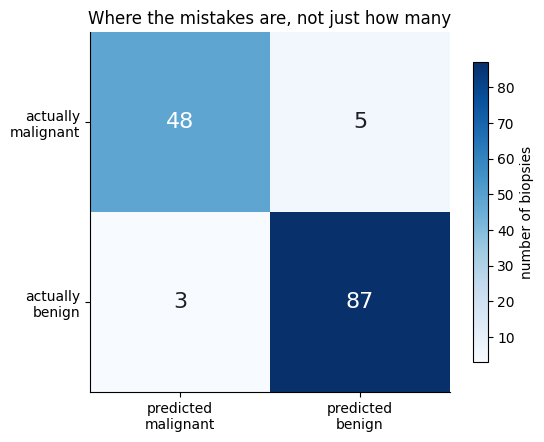

In [12]:
# Rows = truth, columns = prediction. labels=[0, 1] -> malignant first.
cm = confusion_matrix(yc_te, yc_pred, labels=[0, 1])
tp, fn, fp, tn = cm.ravel()   # with malignant (0) as the "positive" class

print("Confusion matrix (malignant = positive):")
print(pd.DataFrame(cm,
                   index=["actually malignant", "actually benign"],
                   columns=["predicted malignant", "predicted benign"]))

print(f"""
In words, out of {len(yc_te)} held-out biopsies:
  {tp:3d} malignant tumours correctly flagged        (true positives)
  {fn:3d} malignant tumours MISSED                   (false negatives) <- the dangerous error
  {fp:3d} benign tumours wrongly flagged             (false positives) <- unnecessary alarm
  {tn:3d} benign tumours correctly cleared           (true negatives)""")

fig, ax = plt.subplots(figsize=(5.6, 4.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["predicted\nmalignant", "predicted\nbenign"])
ax.set_yticks([0, 1], ["actually\nmalignant", "actually\nbenign"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else BAS_INK)
ax.set_title("Where the mistakes are, not just how many")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="number of biopsies")
plt.tight_layout()
plt.show()

### 8c. Precision, recall, F1 — metrics with consequences

Accuracy adds all four cells together and therefore hides *which* mistake you are making. But the two mistakes
are not interchangeable — in this dataset one is "come back for another test", the other is "go home with an
untreated tumour". Precision and recall separate them:

- **Recall** = TP / (TP + FN) — *of all the real cases, how many did we catch?*
  Falls when you **miss** cases. **Maximise recall when a missed case is the expensive error**: cancer screening,
  fraud detection, structural safety inspection, content moderation for imminent harm.
- **Precision** = TP / (TP + FP) — *of everything we flagged, how much was real?*
  Falls when you raise **false alarms**. **Maximise precision when a false accusation is the expensive error**:
  flagging benefit fraud, blocking accounts, spam filtering (a lost job offer in the spam folder is costly).
- **F1** = the harmonic mean of the two — one number when you genuinely need a single summary and both errors
  matter. It is a compromise, and like all compromises it hides the trade-off it made.

**They trade off against each other.** Flag every biopsy as malignant and recall is 100% while precision
collapses; flag only the most obvious cases and precision is high while recall collapses. There is no
mathematically correct balance point — the right one depends on what happens to a person when the model is
wrong, which makes it an ethical and institutional decision, not a technical one. This is precisely the kind of
question the *Bridging AI & Society* framing exists for: the metric you optimise encodes whose harm you have
decided to prioritise.

In [13]:
# malignant is class 0 in this dataset, so pos_label=0
print("Treating MALIGNANT as the positive class:")
print(f"  precision {precision_score(yc_te, yc_pred, pos_label=0):.1%}"
      "  <- of the tumours we flagged, this share really was malignant")
print(f"  recall    {recall_score(yc_te, yc_pred, pos_label=0):.1%}"
      "  <- of the real malignant tumours, this share was caught")
print(f"  F1        {f1_score(yc_te, yc_pred, pos_label=0):.1%}"
      "  <- the balance of the two")

print("\nAll of it at once — classification_report:")
print(classification_report(yc_te, yc_pred, target_names=cancer.target_names, digits=3))

Treating MALIGNANT as the positive class:
  precision 94.1%  <- of the tumours we flagged, this share really was malignant
  recall    90.6%  <- of the real malignant tumours, this share was caught
  F1        92.3%  <- the balance of the two

All of it at once — classification_report:
              precision    recall  f1-score   support

   malignant      0.941     0.906     0.923        53
      benign      0.946     0.967     0.956        90

    accuracy                          0.944       143
   macro avg      0.943     0.936     0.940       143
weighted avg      0.944     0.944     0.944       143



`classification_report` prints precision, recall and F1 **per class**, plus `support` (how many test rows that
class has). Get in the habit of reading it instead of accuracy: it is the same effort and it cannot hide an
imbalance from you.

In a real screening programme, a recall in the low 90s for malignant tumours would be unacceptable — roughly one
in ten cancers missed. The fix is not a cleverer metric; it is a better model, better features, a lower decision
threshold (trading precision away deliberately), or a human radiologist in the loop.

### 8d. Regression metrics — MAE, RMSE, R²

For numbers, we measure *how far off* we are:

| Metric | Definition | Reads as | Character |
|---|---|---|---|
| **MAE** | mean of \|error\| | "typically off by this much" | in the target's own units; easy to explain |
| **RMSE** | √(mean of error²) | "typical error, big ones weighted heavier" | same units; punishes large misses |
| **R²** | share of variance explained | 1.0 = perfect, 0.0 = no better than always predicting the mean, <0 = worse than that | unitless; comparable across datasets |

R² is the one people mis-read: it is the **proportion of the target's variance the model accounts for**, not a
percentage of correct predictions. A regressor makes almost no exactly-correct predictions, so "85% correct" is
not a sentence that can be said about it — and because the yardstick is "always predict the mean", a model that
does worse than that flat line earns a *negative* R².

RMSE ≥ MAE always; the gap between them tells you how skewed your errors are (a few large misses push RMSE up).
And there is no universal "good" value — **good means better than the alternative you would otherwise use**, so
always compute the do-nothing baseline.

In [14]:
mae  = mean_absolute_error(yd_te, yd_pred)
rmse = np.sqrt(mean_squared_error(yd_te, yd_pred))   # sqrt of MSE works in every version
r2   = r2_score(yd_te, yd_pred)

# The do-nothing baseline: always predict the training mean
baseline_pred = np.full_like(yd_te, yd_tr.mean(), dtype=float)

print(f"{'':<22}{'MAE':>9}{'RMSE':>9}{'R2':>9}")
print("-" * 49)
print(f"{'LinearRegression':<22}{mae:>9.1f}{rmse:>9.1f}{r2:>9.3f}")
print(f"{'always the mean':<22}{mean_absolute_error(yd_te, baseline_pred):>9.1f}"
      f"{np.sqrt(mean_squared_error(yd_te, baseline_pred)):>9.1f}"
      f"{r2_score(yd_te, baseline_pred):>9.3f}")
print(f"\nFor scale: the target ranges {yd_te.min():.0f}-{yd_te.max():.0f} "
      f"with a standard deviation of {yd_te.std():.1f}.")

                            MAE     RMSE       R2
-------------------------------------------------
LinearRegression           41.5     53.4    0.485
always the mean            65.5     74.9   -0.014

For scale: the target ranges 37-310 with a standard deviation of 74.4.


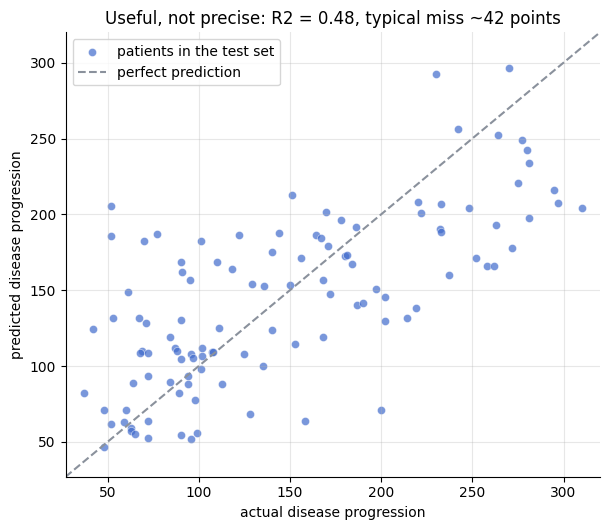

In [15]:
fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.scatter(yd_te, yd_pred, color=BAS_BLUE, alpha=0.7, s=34,
           edgecolors="white", linewidths=0.4, label="patients in the test set")
lims = [min(yd_te.min(), yd_pred.min()) - 10, max(yd_te.max(), yd_pred.max()) + 10]
ax.plot(lims, lims, color=BAS_GREY, ls="--", lw=1.5, label="perfect prediction")
ax.set_xlabel("actual disease progression")
ax.set_ylabel("predicted disease progression")
ax.set_title(f"Useful, not precise: R2 = {r2:.2f}, typical miss ~{mae:.0f} points")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()
plt.tight_layout()
plt.show()

So what counts as "good here"? The model is **typically off by about 42 points** (MAE 41.5) on a target whose
test values run from 37 to 310 with a standard deviation of about 74. That is clearly informative — it explains
not quite half the variance (R² 0.485) and beats the do-nothing baseline substantially: always predicting the
mean gives MAE 65.5 and R² −0.014 — a whisker *below* zero, because that flat line was fitted with the *training*
mean, which is not quite the test set's own mean. (A negative R² is not a bug; it is the metric saying "worse
than a flat line".) And the model is still nowhere near precise enough to support an individual clinical
decision. Both statements are true at once, and saying only the flattering one is how models get oversold.

The scatter plot shows the characteristic shape of an honest-but-limited regressor: the cloud follows the
diagonal, so the model has the trend, but it is wide, and it is **compressed** — high values are under-predicted,
low values over-predicted. Regression pulled towards the mean is normal; it is the model hedging where the
features do not tell it enough.

## 9. Overfitting and generalisation — the central idea

If you remember one thing from this notebook, remember this section.

- **Generalisation** is the only goal. A model is useful because it performs on data it has never seen.
- **Underfitting**: the model is too rigid to capture the real pattern. Bad on training data *and* on test data.
- **Overfitting**: the model is flexible enough to memorise the noise in the training data — the accidents of
  *these* particular rows. Excellent on training data, poor on test data.

Between the two lies the **sweet spot**, and you find it by watching *both* scores as you increase model
flexibility. Let's do exactly that. The data below has a genuine pattern (two groups arranged diagonally, in
opposite corners) plus 5% randomly flipped labels — noise no model could ever get right. We fit decision trees
of increasing `max_depth`, which is a clean flexibility dial: depth 1 draws one line, deep trees can carve out a
box around every single point.

In [16]:
def make_corner_data(n, seed=7, noise=0.05):
    """Two classes in diagonally opposite corners + a few flipped labels."""
    X, blob = make_blobs(n_samples=n, centers=[(-2, -2), (2, 2), (-2, 2), (2, -2)],
                         cluster_std=1.0, random_state=seed)
    y = np.where(np.isin(blob, [0, 1]), 0, 1)          # diagonal pairs share a class
    rng = np.random.default_rng(seed)
    y = np.where(rng.random(n) < noise, 1 - y, y)      # flip ~5% of the labels
    return X, y

X_of, y_of = make_corner_data(400)
Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(
    X_of, y_of, test_size=0.35, random_state=RANDOM_STATE, stratify=y_of)

depths = range(1, 16)
train_scores, test_scores = [], []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(Xo_tr, yo_tr)
    train_scores.append(m.score(Xo_tr, yo_tr))
    test_scores.append(m.score(Xo_te, yo_te))

best_depth = int(np.argmax(test_scores)) + 1
print(f"{'max_depth':>10}{'train':>9}{'test':>9}{'gap':>9}")
print("-" * 37)
for d, tr, te in zip(depths, train_scores, test_scores):
    flag = "  <- best test score" if d == best_depth else ""
    print(f"{d:>10}{tr:>9.1%}{te:>9.1%}{tr - te:>9.1%}{flag}")

 max_depth    train     test      gap
-------------------------------------
         1    57.3%    48.6%     8.7%
         2    74.6%    66.4%     8.2%
         3    92.7%    88.6%     4.1%  <- best test score
         4    93.8%    86.4%     7.4%
         5    95.8%    84.3%    11.5%
         6    97.7%    84.3%    13.4%
         7    99.2%    80.7%    18.5%
         8    99.6%    80.0%    19.6%
         9   100.0%    80.7%    19.3%
        10   100.0%    80.7%    19.3%
        11   100.0%    80.7%    19.3%
        12   100.0%    80.7%    19.3%
        13   100.0%    80.7%    19.3%
        14   100.0%    80.7%    19.3%
        15   100.0%    80.7%    19.3%


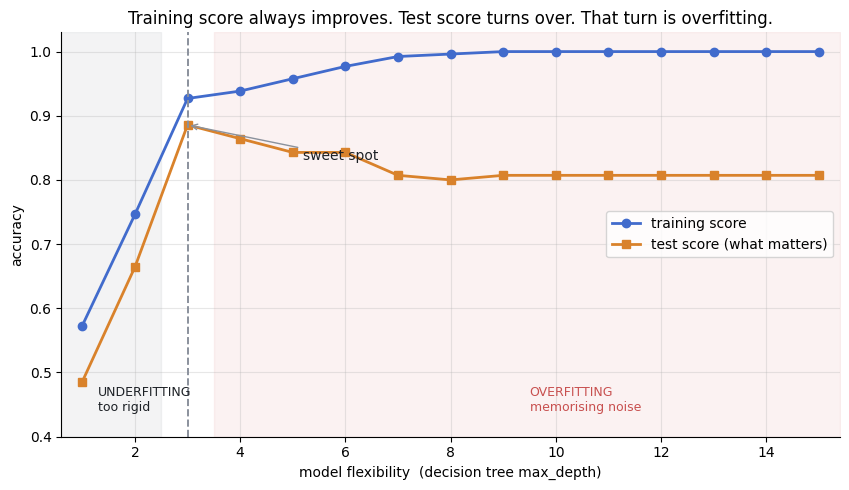

In [17]:
fig, ax = plt.subplots(figsize=(8.6, 5))
ax.plot(list(depths), train_scores, "o-", color=BAS_BLUE, lw=2, label="training score")
ax.plot(list(depths), test_scores, "s-", color=BAS_AMBER, lw=2, label="test score (what matters)")
ax.axvline(best_depth, color=BAS_GREY, ls="--", lw=1.4)
ax.annotate("sweet spot", xy=(best_depth, max(test_scores)),
            xytext=(best_depth + 2.2, max(test_scores) - 0.055),
            color=BAS_INK, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=BAS_GREY))
ax.fill_between([0.6, best_depth - 0.5], 0.4, 1.03, color=BAS_GREY, alpha=0.10)
ax.fill_between([best_depth + 0.5, 15.4], 0.4, 1.03, color=BAS_RED, alpha=0.07)
ax.text(1.3, 0.44, "UNDERFITTING\ntoo rigid", fontsize=9, color=BAS_INK)
ax.text(9.5, 0.44, "OVERFITTING\nmemorising noise", fontsize=9, color=BAS_RED)
ax.set_xlabel("model flexibility  (decision tree max_depth)")
ax.set_ylabel("accuracy")
ax.set_ylim(0.40, 1.03)
ax.set_xlim(0.6, 15.4)
ax.set_title("Training score always improves. Test score turns over. That turn is overfitting.")
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

This picture is the whole lesson:

- **The blue curve only ever goes up.** More flexibility always fits the training data better — at depth 9 and
  beyond the tree scores 100% on data it has already seen. A rising training score is therefore *no evidence of
  anything*.
- **The amber curve rises, peaks, and falls.** Up to the sweet spot, extra flexibility captures real structure.
  After it, extra flexibility captures the 5% of labels we flipped at random — patterns that exist in the
  training rows and nowhere else in the universe.
- **The gap between the curves is the overfitting.** From the sweet spot onwards it widens sharply — about 4
  points at depth 3, 11 at depth 5, 19 by depth 8 — and then stops growing only because the training score has
  run out of room at 100%.

At depth 1 and 2 the tree is worse on *both* sets: with a single split it cannot express "opposite corners
belong together" at all. That is underfitting, and the cure is the opposite one — more flexibility, better
features.

Let's see what the boundary actually looks like at three points on that curve.

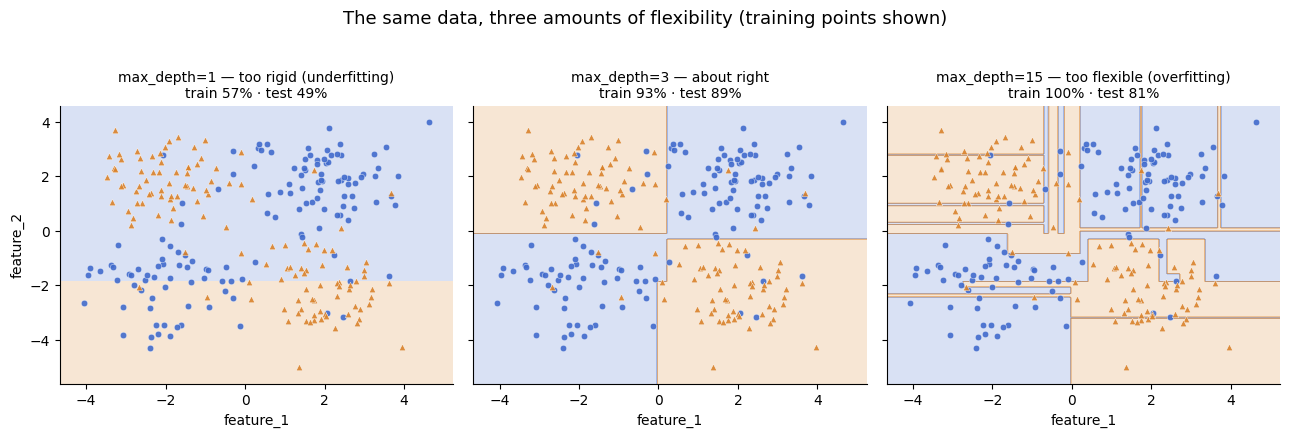

In [18]:
def plot_boundary(ax, model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.20, cmap=ListedColormap([BAS_BLUE, BAS_AMBER]))
    for group, colour, marker in [(0, BAS_BLUE, "o"), (1, BAS_AMBER, "^")]:
        sel = y == group
        ax.scatter(X[sel, 0], X[sel, 1], color=colour, marker=marker, s=22,
                   alpha=0.9, edgecolors="white", linewidths=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("feature_1")
    ax.grid(False)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for ax, d, label in zip(axes, [1, best_depth, 15],
                        ["too rigid (underfitting)", "about right", "too flexible (overfitting)"]):
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(Xo_tr, yo_tr)
    plot_boundary(ax, m, Xo_tr, yo_tr,
                  f"max_depth={d} — {label}\ntrain {m.score(Xo_tr, yo_tr):.0%} · test {m.score(Xo_te, yo_te):.0%}")
axes[0].set_ylabel("feature_2")
fig.suptitle("The same data, three amounts of flexibility (training points shown)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

Look at the right-hand panel: thin slivers of colour reaching out to capture individual points. Each sliver is
the tree accommodating one flipped label. It is *correct* about that training point and wrong about the region
of reality around it. That is what memorising noise looks like when you can draw it.

### Why more data and simpler models help

Two levers, and the picture above explains both.

- **A simpler model cannot draw the slivers.** Constraining flexibility (`max_depth`, fewer features, a linear
  model instead of a tree, regularisation) removes the capacity to memorise. This is why "start simple" is not
  timidity but method.
- **More data drowns the noise.** A sliver around one odd point is only worth drawing if that point is alone. Add
  more observations and the real pattern gets voted for repeatedly while the accidents do not.

In [19]:
print("Same fully-flexible tree (no depth limit), increasing amounts of data:")
print(f"{'n samples':>10}{'train':>9}{'test':>9}{'gap':>9}")
print("-" * 37)
for n in (100, 200, 400, 1600, 6400):
    Xn, yn = make_corner_data(n)
    Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
        Xn, yn, test_size=0.35, random_state=RANDOM_STATE, stratify=yn)
    m = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xn_tr, yn_tr)
    tr, te = m.score(Xn_tr, yn_tr), m.score(Xn_te, yn_te)
    print(f"{n:>10}{tr:>9.1%}{te:>9.1%}{tr - te:>9.1%}")

Same fully-flexible tree (no depth limit), increasing amounts of data:
 n samples    train     test      gap
-------------------------------------
       100   100.0%    71.4%    28.6%
       200   100.0%    72.9%    27.1%
       400   100.0%    80.7%    19.3%
      1600   100.0%    82.1%    17.9%
      6400   100.0%    84.6%    15.4%


The training score stays pinned at 100% — an unrestricted tree always memorises. But the **test score climbs and
the gap shrinks by roughly half** as the data grows. Same model, same noise level, better generalisation, purely
from more examples.

Do not over-read it, though. Even with 6400 points the unrestricted tree reaches 84.6%, while the depth-3 tree back
in section 9 got **88.6% from only 400 points**. More data helped; it did not substitute for the simpler model.
The two levers are cheapest used together.

This is also the honest reason so much of modern ML is a data story rather than an algorithm story — and it has a
sharp corollary: **more data of the same kind** helps you generalise *to that kind*. Ten times as many
measurements from one hospital will not teach your model about a different patient population. That is limit 3 in
section 11.

## 10. A complete example you can re-run and modify

All eight steps, one dataset, one cell — the **wine** data: 178 Italian wines, 13 chemical measurements, three
cultivars. Change `MAX_DEPTH`, `TEST_SIZE` or the model class and re-run; that experimentation is the point.

1-2  178 wines x 13 features · missing: 0 · classes: [59 71 48]
3    train 133 / test 45
4-5  DecisionTreeClassifier(max_depth=3) fitted
6-7  baseline accuracy 40.0%  ->  model accuracy 95.6%  (train 99.2%)

              precision    recall  f1-score   support

     class_0      1.000     0.933     0.966        15
     class_1      0.900     1.000     0.947        18
     class_2      1.000     0.917     0.957        12

    accuracy                          0.956        45
   macro avg      0.967     0.950     0.956        45
weighted avg      0.960     0.956     0.956        45

Confusion matrix (rows = truth, columns = prediction):
            said class_0  said class_1  said class_2
is class_0            14             1             0
is class_1             0            18             0
is class_2             0             1            11


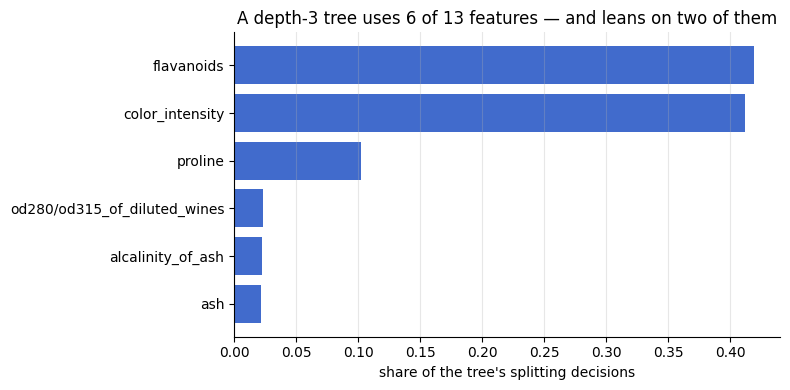

In [20]:
# ============ Knobs to play with ============
MAX_DEPTH = 3
TEST_SIZE = 0.25
# ============================================

# STEP 1 — question: from 13 chemical measurements, which of 3 cultivars is this wine?
wine = load_wine()
X, y = wine.data, wine.target

# STEP 2 — inspect and clean
print(f"1-2  {X.shape[0]} wines x {X.shape[1]} features · "
      f"missing: {np.isnan(X).sum()} · classes: {np.bincount(y)}")

# STEP 3 — split (stratified, seeded)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f"3    train {len(X_tr)} / test {len(X_te)}")

# STEPS 4-5 — choose and fit; a trivial baseline for comparison
baseline = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
model = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=RANDOM_STATE).fit(X_tr, y_tr)
print(f"4-5  DecisionTreeClassifier(max_depth={MAX_DEPTH}) fitted")

# STEP 6 — predict
y_hat = model.predict(X_te)

# STEP 7 — evaluate: baseline, then the model, then per class
print(f"6-7  baseline accuracy {baseline.score(X_te, y_te):.1%}"
      f"  ->  model accuracy {accuracy_score(y_te, y_hat):.1%}"
      f"  (train {model.score(X_tr, y_tr):.1%})")
print()
print(classification_report(y_te, y_hat, target_names=wine.target_names, digits=3))
print("Confusion matrix (rows = truth, columns = prediction):")
print(pd.DataFrame(confusion_matrix(y_te, y_hat),
                   index=[f"is {c}" for c in wine.target_names],
                   columns=[f"said {c}" for c in wine.target_names]))

# STEP 8 — iterate: which features is the model actually using?
importance = pd.Series(model.feature_importances_, index=wine.feature_names)
importance = importance[importance > 0].sort_values(ascending=False)
n_used = len(importance)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index[::-1], importance.values[::-1], color=BAS_BLUE)
ax.set_xlabel("share of the tree's splitting decisions")
ax.set_title(f"A depth-{MAX_DEPTH} tree uses {n_used} of {X.shape[1]} features — "
             "and leans on two of them")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.show()

Things worth noticing in that output, because they are the habits you want:

- The **baseline is reported next to the model**, so the accuracy figure means something.
- The train/test gap is small — this depth-3 tree is not memorising.
- `classification_report` shows the per-class picture, not one aggregate number.
- The importance chart shows that a depth-3 tree touches only **6 of the 13 features**, and that **two of them
  (flavanoids and colour intensity) account for more than 80%** of its splitting decisions. That is a fact about
  *this fitted model*, not about wine chemistry: the seven unused features may well be informative, just
  redundant given the splits the tree happened to choose. Feature importance describes the model, not the world.

## 11. Honest limits — what a trained model does not give you

Everything above is real and useful. These four caveats are equally real, and knowing them is part of being
competent, not a disclaimer bolted on at the end.

**1. Correlation is not causation, and models only learn correlation.**
A model that predicts `y` from `X` has found that they *move together in this dataset*. It cannot tell you that
changing `X` would change `y`. The classic failure: ice-cream sales predict drowning deaths (both follow summer);
banning ice cream saves nobody. Whenever someone proposes to *intervene* on the basis of a predictive model, that
is a causal claim, and predictive accuracy is not evidence for it.

**2. A model reproduces the patterns in its training data — including the unfair ones.**
"The algorithm is objective" is a category error. If historical hiring decisions favoured one group, a model
trained to predict "was hired" learns to favour that group, and does so consistently, at scale, and with an air
of neutrality. Bias does not need a biased variable: proxies (postcode, school, name, purchase history) carry it
in. Nor is the training data ever a neutral sample — it is whatever somebody recorded, about whoever they were
recording, for their own purposes. Ask *who is in this data, who is missing, and who decided what to record*
before you ask which model to use.

**3. A good test score is not proof of real-world safety.**
Your test set came from the same collection process as your training set, so it can only tell you how the model
behaves on *that* kind of data. It says nothing about next year, about a different hospital or country, about
inputs someone deliberately crafted to fool the model, or about how people will change their behaviour once they
know the model exists. Distributions shift; deployed models degrade quietly.

**4. The metric is a value judgement in disguise.**
We chose to weight missed tumours against false alarms in section 8c. That choice was not in the data. Someone
always makes it — and the honest move is to make it explicitly, with the affected people represented, rather
than by accepting whatever `.score()` happens to return.

None of this is a reason not to use machine learning. It is the reason to state what your model was trained on,
what it is scored on, what error it makes most often, and who bears the cost of that error — every time you
report a result.

---

## 🧪 Practice exercises

Five exercises, building on each other. Try each one before opening the solution — the ideas stick only if you
have wrestled with them for a minute first.

### Exercise 12.1 — Split it yourself

Using `load_wine()`:

1. Split into 70% train / 30% test with `random_state=42` and stratification on `y`.
2. Print the number of rows in each half, plus the class proportions of the full data, the training half and the
   test half (rounded to three decimals) — then check how closely they line up.
3. Fit a `DecisionTreeClassifier(max_depth=2)` and print **both** the training and the test accuracy.
4. In a comment: which of the two accuracy numbers would you put in a report, and why?

In [21]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
wine_ex = load_wine()
Xa, Xb, ya, yb = train_test_split(
    wine_ex.data, wine_ex.target,
    test_size=0.3, random_state=42, stratify=wine_ex.target,
)

print(f"train {len(Xa)} rows / test {len(Xb)} rows")
print(pd.DataFrame({
    "full" : np.bincount(wine_ex.target) / len(wine_ex.target),
    "train": np.bincount(ya) / len(ya),
    "test" : np.bincount(yb) / len(yb),
}, index=wine_ex.target_names).round(3))

tree = DecisionTreeClassifier(max_depth=2, random_state=42).fit(Xa, ya)
print(f"train accuracy {tree.score(Xa, ya):.1%}")
print(f"test  accuracy {tree.score(Xb, yb):.1%}")

# Report the TEST accuracy: it is the only one measured on data the model
# has never seen, and therefore the only estimate of future performance.
```

Expected output: 124 training rows and 54 test rows; proportions of roughly 0.331 / 0.399 / 0.270 in the full
data, reproduced to within about one percentage point in both halves; train accuracy about 93.5% and test
accuracy about 88.9%.

**Reasoning.** `stratify=y` is what keeps those three proportions aligned — drop it and the smallest class can
drift by several points, which matters more the rarer the class. The train score exceeding the test score by a
few points is entirely normal; it is the *size* of that gap you monitor. And the number that goes in the report
is the test score, because a model is only worth what it does on data it has not seen.

</details>

### Exercise 12.2 — The same data, two questions

The diabetes target is a number, so `load_diabetes()` is a regression problem. But the *framing* is a choice you
make, not a property of the data.

1. Fit a `LinearRegression` on a 75/25 split (`random_state=42`) and print MAE and R².
2. Now turn the same target into a **binary** one: `y_class = (y > median).astype(int)`, i.e. "above or below
   typical progression".
3. Split again (same settings, plus `stratify=y_class`), fit a `DecisionTreeClassifier(max_depth=3)`, and print
   its accuracy.
4. In a comment: what did the classification framing gain, and what did it throw away?

In [22]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
db = load_diabetes()

# --- as a regression problem -------------------------------------------
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    db.data, db.target, test_size=0.25, random_state=42)
lin = LinearRegression().fit(Xr_tr, yr_tr)
pred = lin.predict(Xr_te)
print(f"regression : MAE {mean_absolute_error(yr_te, pred):.1f}, "
      f"R2 {r2_score(yr_te, pred):.3f}")

# --- as a classification problem ---------------------------------------
threshold = np.median(db.target)
y_class = (db.target > threshold).astype(int)
print(f"threshold (median target) = {threshold:.1f}, class counts {np.bincount(y_class)}")

Xc_tr2, Xc_te2, yc_tr2, yc_te2 = train_test_split(
    db.data, y_class, test_size=0.25, random_state=42, stratify=y_class)
clf2 = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xc_tr2, yc_tr2)
print(f"classification : accuracy {clf2.score(Xc_te2, yc_te2):.1%}")

# Gained: a simple, actionable output ("above/below typical") that is easy to
# communicate, and a metric anyone understands.
# Threw away: everything inside each bin. A patient just above the threshold
# and one at the maximum are now indistinguishable, and the cut point itself
# is an arbitrary decision that is now baked into every prediction.
```

Expected output: regression MAE ≈ 41.5 with R² ≈ 0.485; a median threshold of 140.5 splitting the data
221 / 221; classification accuracy ≈ 69.4%.

**Reasoning.** The two numbers are *not* comparable — 69% accuracy and R² 0.485 measure different things on
different targets, so neither framing is "better" by score. What changed is the question. Binning a continuous
target is sometimes exactly right (when the decision it feeds really is binary) and often a quiet loss of
information, and the threshold is a policy choice: move the median cut to the 90th percentile and you have an
imbalanced problem where accuracy stops meaning anything, as in section 8a.

</details>

### Exercise 12.3 — Read the confusion matrix out loud

Re-use the breast-cancer model from section 7a (`cancer_clf`, `yc_te`, `yc_pred`), or refit it.

1. Print the confusion matrix with `labels=[0, 1]` so that malignant comes first.
2. Unpack the four cells and print one sentence per cell, in words, naming which is the *dangerous* error.
3. Compute the **recall for malignant by hand** from those four numbers, and check it against
   `recall_score(..., pos_label=0)`.
4. In a comment: if this were a real screening tool, which cell would you attack first?

In [23]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
cm3 = confusion_matrix(yc_te, yc_pred, labels=[0, 1])
print(cm3)

# labels=[0, 1] with malignant = 0 treated as the positive class:
tp3, fn3, fp3, tn3 = cm3.ravel()
print(f"{tp3} malignant tumours correctly flagged   (true positive)")
print(f"{fn3} malignant tumours missed              (FALSE NEGATIVE - the dangerous one)")
print(f"{fp3} benign tumours wrongly flagged        (false positive - a false alarm)")
print(f"{tn3} benign tumours correctly cleared      (true negative)")

recall_by_hand = tp3 / (tp3 + fn3)
print(f"\nrecall by hand      {recall_by_hand:.4f}")
print(f"recall_score()      {recall_score(yc_te, yc_pred, pos_label=0):.4f}")

# Attack the false negatives first: a missed malignant tumour means an
# untreated cancer, whereas a false positive means an anxious patient and a
# second test. Accepting more false alarms to catch more real cases is the
# right trade here -- and that is a judgement about harm, not about maths.
```

Expected output: the matrix `[[48, 5], [3, 87]]` — so 48 malignant caught, 5 missed, 3 benign wrongly flagged,
87 correctly cleared — and both recall computations agreeing at 0.9057.

**Reasoning.** `confusion_matrix(...).ravel()` returns the cells in row-major order, so *which* name belongs to
which cell depends entirely on the `labels=` order you passed. Getting that mapping wrong silently swaps
precision and recall — one of the most common quiet bugs in ML reporting, and a good reason to print a labelled
DataFrame rather than a bare array. Reproducing the metric by hand once is the cheapest way to be sure you know
what `pos_label` is doing.

</details>

### Exercise 12.4 — Find the sweet spot

Using the wine training/test split from section 5 (`X_train`, `X_test`, `y_train`, `y_test`):

1. For `max_depth` from 1 to 10, fit a `DecisionTreeClassifier(random_state=42)` and record train and test accuracy.
2. Plot both curves on one axes — training in `BAS_BLUE`, test in `BAS_AMBER` — with labelled axes and a
   takeaway title.
3. Print the depth with the best test score.
4. In a comment: at which depth does the training score reach 100%, and does the test score improve after that?

In [24]:
# Your code here  👇

<details>
<summary>💡 Click to reveal the solution</summary>

```python
depth_range = range(1, 11)
tr_acc, te_acc = [], []
for d in depth_range:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    tr_acc.append(m.score(X_train, y_train))
    te_acc.append(m.score(X_test, y_test))

best = int(np.argmax(te_acc)) + 1
print(f"best test accuracy {max(te_acc):.1%} at max_depth={best}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(depth_range), tr_acc, "o-", color=BAS_BLUE, lw=2, label="training accuracy")
ax.plot(list(depth_range), te_acc, "s-", color=BAS_AMBER, lw=2, label="test accuracy")
ax.axvline(best, color=BAS_GREY, ls="--", lw=1.3)
ax.set_xlabel("max_depth (model flexibility)")
ax.set_ylabel("accuracy")
ax.set_title("Wine: depth 3 is enough — deeper trees only fit the training set better")
ax.legend()
plt.tight_layout()
plt.show()

# The training score hits 100% at max_depth=4 and stays there; the test score
# is already at its maximum by depth 3 and never improves again. Everything
# beyond depth 3 is pure memorisation -- flexibility spent on nothing.
```

Expected output: `best test accuracy 95.6% at max_depth=3`; training accuracy climbing 66.2% → 94.0% → 99.3% →
100.0% for depths 1–4 and flat thereafter, with the test curve flat at 95.6% from depth 3 onwards.

**Reasoning.** Wine is an easy, well-separated dataset, so the test curve plateaus rather than dropping sharply
— overfitting does not always look dramatic. The rule still holds: **pick the simplest model at the plateau**,
not the most flexible one that ties it. A depth-3 tree is faster, easier to explain, and less exposed to noise in
data you have not seen yet. (Strictly, choosing a depth by looking at the test score is the mistake warned about
in section 5 — with a real project you would choose it by cross-validation on the training set. That is exactly
what notebook 13 builds.)

</details>

### Exercise 12.5 — Debug me 🐞

The cell below **runs without any error** and prints a beautiful result. It is nevertheless wrong in a way that
would get a paper rejected.

Run it, look hard at the number, and find the bug. Then fix it and report the honest figure.

*Hint: an accuracy of exactly 100% is almost never good news.*

In [25]:
# Buggy — this runs fine, which is exactly the problem. What is wrong?
wine_bug = load_wine()
Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(
    wine_bug.data, wine_bug.target, test_size=0.25,
    random_state=RANDOM_STATE, stratify=wine_bug.target,
)

model_bug = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_bug.fit(Xg_tr, yg_tr)

accuracy = model_bug.score(Xg_tr, yg_tr)
print(f"Our classifier achieves {accuracy:.1%} accuracy on the wine dataset!")

Our classifier achieves 100.0% accuracy on the wine dataset!


<details>
<summary>💡 Click to reveal the solution</summary>

The model is **scored on the data it was trained on**: `model_bug.score(Xg_tr, yg_tr)` passes the *training*
features and labels. The test set was created and then never used. That reported "100% accuracy" is the exam
with the answer sheet attached (section 5) — and an unrestricted decision tree will always ace it, because it
grows branches until every training row is filed away individually.

```python
wine_fix = load_wine()
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    wine_fix.data, wine_fix.target, test_size=0.25,
    random_state=RANDOM_STATE, stratify=wine_fix.target,
)

model_fix = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xf_tr, yf_tr)

print(f"training accuracy (meaningless) : {model_fix.score(Xf_tr, yf_tr):.1%}")
print(f"TEST accuracy (the real number) : {model_fix.score(Xf_te, yf_te):.1%}")

# Bonus: a simpler tree generalises just as well here.
simpler = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(Xf_tr, yf_tr)
print(f"depth-3 tree, test accuracy     : {simpler.score(Xf_te, yf_te):.1%}")
```

Expected output: training accuracy 100.0%, test accuracy 95.6%, and the depth-3 tree also at 95.6%.

**Reasoning.** Note what makes this bug nasty: nothing raises, nothing warns, and the output looks like success.
The only defence is a habit — *the object you score must be the one you never fitted on* — plus healthy suspicion
of perfect scores. The same bug wears other disguises: fitting a scaler on the full dataset before splitting,
selecting features using all the labels, or tuning hyperparameters against the test set until it flatters you.
All of them leak information from the answer sheet into training, and all of them produce numbers that quietly
fail to survive contact with new data.

</details>

---

## 🧠 Key takeaways

1. **Machine learning inverts programming.** You supply examples and answers; the algorithm supplies the rule.
   A model is a **function fitted to data** — `.fit()` learns it, `.predict()` applies it.
2. **Supervised** learning has labels (`X` *and* `y`); **unsupervised** learning has only `X`. Clusters are
   invented groups, not discovered truths — their numbering is arbitrary and they need not match any real class.
3. **`X` is 2-D** (rows = observations, columns = features), **`y` is 1-D**, and row `i` of `X` belongs to `y[i]`.
   **Feature engineering** is where your domain knowledge — and your assumptions — enter the model.
4. **Never score a model on its training data.** Split with `train_test_split(..., random_state=42, stratify=y)`,
   split *before* any other processing, and look at the test set once.
5. **The workflow loop**: define → get/clean → split → choose → fit → predict → evaluate → iterate. Iterating
   means changing features or model, never re-splitting until the number pleases you.
6. **Classification** predicts a category, **regression** predicts a number. Identical API, different metrics.
7. **Accuracy lies on imbalanced data** — "nobody is ill" scored 95%. Read the **confusion matrix**; choose
   **recall** when missing a case is the costly error and **precision** when a false alarm is. For regression use
   **MAE / RMSE / R²** and always beat the do-nothing baseline.
8. **Overfitting is the central problem.** Training score always rises with flexibility; test score peaks and
   then falls. Watch both curves, prefer the simplest model at the plateau, and get more data when you can.
9. **A model reproduces its training data**, correlation is not causation, and a good test score is not a safety
   guarantee. State what your model was trained on, which error it makes most, and who pays for that error.

## ✅ Self-assessment

- [ ] I can explain to a non-programmer how ML differs from writing rules by hand.
- [ ] I can say what makes a problem supervised or unsupervised, and why clusters are not classes.
- [ ] I can put a dataset into `X` / `y` form and explain the shape of each.
- [ ] I can justify a train/test split with the exam analogy, and say what `random_state` and `stratify` do.
- [ ] I can recite the eight-step workflow loop from memory.
- [ ] I can tell a classification problem from a regression problem and pick a starter model for each.
- [ ] I can read a confusion matrix aloud and name the dangerous cell for a given application.
- [ ] I can say when accuracy is the wrong metric, and choose precision or recall from the consequences.
- [ ] I can recognise underfitting and overfitting in a train-vs-test curve and name two remedies.
- [ ] I can state three honest limits of a model that scores well on its test set.

## 🚀 Next step

You now have the mental models. Next comes the craft:
**[Notebook 13 — The Scikit-Learn Workflow](13_scikit_learn_workflow.ipynb)**, where the same ideas become
professional practice: `Pipeline` (so that scaling can never leak across the split), `cross_val_score` (so that
a single lucky split cannot fool you), `GridSearchCV` (so that hyperparameters are chosen honestly), and a
side-by-side comparison of several model families.